In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Affichage des graphiques directement dans le notebook
%matplotlib inline

In [96]:
# Chargement des données brutes
df = pd.read_csv('../data/raw/pl_24-25_matches_clean.csv')

# Affichage des premières lignes
df.head()

,id,gameweek,dayofweek,date,start_time,home_team,home_xg,score,away_xg,away_team,attendance,venue,referee,notes,last_updated
0,1,1,Fri,2024-08-16,20:00,Manchester Utd,2.4,1–0,0.4,Fulham,NaN,Old Trafford,Robert Jones,NaN,2026-01-13 18:34:33.302
1,2,1,Sat,2024-08-17,12:30,Ipswich Town,0.5,0–2,2.6,Liverpool,NaN,Portman Road Stadium,Tim Robinson,NaN,2026-01-13 18:34:33.302
2,3,1,Sat,2024-08-17,15:00,Newcastle Utd,0.3,1–0,1.8,Southampton,NaN,St James' Park,Craig Pawson,NaN,2026-01-13 18:34:33.302
3,4,1,Sat,2024-08-17,15:00,Everton,0.5,0–3,1.4,Brighton,NaN,Goodison Park,Simon Hooper,NaN,2026-01-13 18:34:33.302
4,5,1,Sat,2024-08-17,15:00,Nott'ham Forest,1.3,1–1,1.2,Bournemouth,NaN,The City Ground,Michael Oliver,NaN,2026-01-13 18:34:33.302


In [97]:
# infos sur les colonnes, types et valeurs manquantes
df.info()

# Statistiques descriptives
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            380 non-null    int64  
 1   gameweek      380 non-null    int64  
 2   dayofweek     380 non-null    str    
 3   date          380 non-null    str    
 4   start_time    380 non-null    str    
 5   home_team     380 non-null    str    
 6   home_xg       380 non-null    float64
 7   score         380 non-null    str    
 8   away_xg       380 non-null    float64
 9   away_team     380 non-null    str    
 10  attendance    0 non-null      float64
 11  venue         380 non-null    str    
 12  referee       380 non-null    str    
 13  notes         0 non-null      float64
 14  last_updated  380 non-null    str    
dtypes: float64(4), int64(2), str(9)
memory usage: 44.7 KB


,id,gameweek,home_xg,away_xg,attendance,notes
count,380.000000,380.000000,380.000000,380.000000,0.0,0.0
mean,190.500000,19.500000,1.492105,1.342895,NaN,NaN
std,109.840794,10.980313,0.821634,0.812194,NaN,NaN
min,1.000000,1.000000,0.100000,0.000000,NaN,NaN
25%,95.750000,10.000000,0.900000,0.800000,NaN,NaN
50%,190.500000,19.500000,1.300000,1.200000,NaN,NaN
75%,285.250000,29.000000,2.000000,1.700000,NaN,NaN
max,380.000000,38.000000,4.400000,5.600000,NaN,NaN


In [98]:
# Vérification des valeurs manquantes et doublons
print("Valeurs manquantes par colonne:\n", df.isna().sum())
print("Doublons:\n", df.duplicated().sum())

Valeurs manquantes par colonne:
 id                0
gameweek          0
dayofweek         0
date              0
start_time        0
home_team         0
home_xg           0
score             0
away_xg           0
away_team         0
attendance      380
venue             0
referee           0
notes           380
last_updated      0
dtype: int64
Doublons:
 0


In [99]:
# ignorons les colonnes attendance et notes
df_eda = df.drop(columns=['attendance', 'notes'])
df_eda.head()

,id,gameweek,dayofweek,date,start_time,home_team,home_xg,score,away_xg,away_team,venue,referee,last_updated
0,1,1,Fri,2024-08-16,20:00,Manchester Utd,2.4,1–0,0.4,Fulham,Old Trafford,Robert Jones,2026-01-13 18:34:33.302
1,2,1,Sat,2024-08-17,12:30,Ipswich Town,0.5,0–2,2.6,Liverpool,Portman Road Stadium,Tim Robinson,2026-01-13 18:34:33.302
2,3,1,Sat,2024-08-17,15:00,Newcastle Utd,0.3,1–0,1.8,Southampton,St James' Park,Craig Pawson,2026-01-13 18:34:33.302
3,4,1,Sat,2024-08-17,15:00,Everton,0.5,0–3,1.4,Brighton,Goodison Park,Simon Hooper,2026-01-13 18:34:33.302
4,5,1,Sat,2024-08-17,15:00,Nott'ham Forest,1.3,1–1,1.2,Bournemouth,The City Ground,Michael Oliver,2026-01-13 18:34:33.302


In [100]:
# conversion des types date en datetime
df_eda['date'] = pd.to_datetime(df_eda['date'])
df_eda['start_time'] = pd.to_datetime(df_eda['start_time'], format='%H:%M').dt.time

In [101]:
# listons les équipes jouant à domicile et à l'exterieur ( vérifions dans la foulée s'il y a effectivement 20 equipes)
teams_home = df_eda['home_team'].unique()
teams_away = df_eda['away_team'].unique()
teams = set(teams_home) | set(teams_away)
print("Nombre d'équipes :", len(teams))
print("Equipes :", sorted(teams))

Nombre d'équipes : 20
Equipes : ['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Ipswich Town', 'Leicester City', 'Liverpool', 'Manchester City', 'Manchester Utd', 'Newcastle Utd', "Nott'ham Forest", 'Southampton', 'Tottenham', 'West Ham', 'Wolves']


In [102]:
# Statistiques des equipes (en terme de xG domicile comme exterieur)
df.groupby('home_team')['home_xg'].mean().sort_values(ascending=False)
df.groupby('away_team')['away_xg'].mean().sort_values(ascending=False)

away_team
Liverpool          2.194737
Bournemouth        1.721053
Chelsea            1.615789
Newcastle Utd      1.615789
Manchester City    1.615789
Arsenal            1.594737
Crystal Palace     1.568421
Brighton           1.473684
Fulham             1.415789
Tottenham          1.336842
West Ham           1.284211
Brentford          1.257895
Manchester Utd     1.184211
Aston Villa        1.178947
Nott'ham Forest    1.178947
Wolves             1.063158
Everton            0.994737
Ipswich Town       0.921053
Leicester City     0.831579
Southampton        0.810526
Name: away_xg, dtype: float64

In [103]:
# extraction des buts mis à domicile comme à l'exterieur depuis la colonne score
df_eda[['home_goals','away_goals']] = df_eda['score'].str.split('–', expand=True).astype(int)

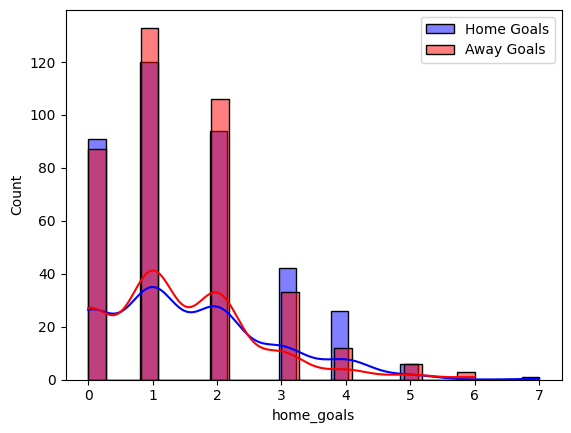

In [104]:
# Verification de la distribution des scores
sns.histplot(df_eda['home_goals'], kde=True, color='blue', label='Home Goals')
sns.histplot(df_eda['away_goals'], kde=True, color='red', label='Away Goals')
plt.legend()
plt.show()

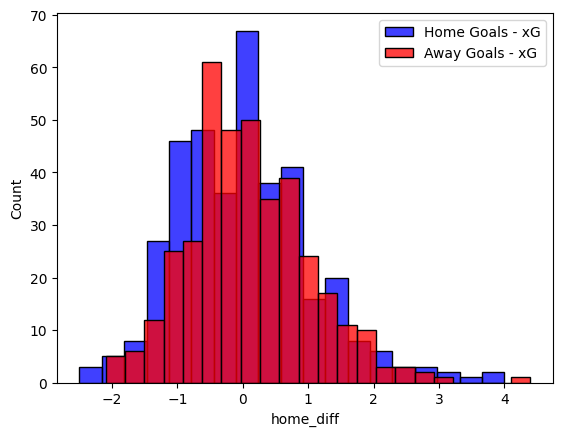

In [105]:
df_eda['home_diff'] = df_eda['home_goals'] - df_eda['home_xg']
df_eda['away_diff'] = df_eda['away_goals'] - df_eda['away_xg']
sns.histplot(df_eda['home_diff'], color='blue', label='Home Goals - xG')
sns.histplot(df_eda['away_diff'], color='red', label='Away Goals - xG')
plt.legend()
plt.show()

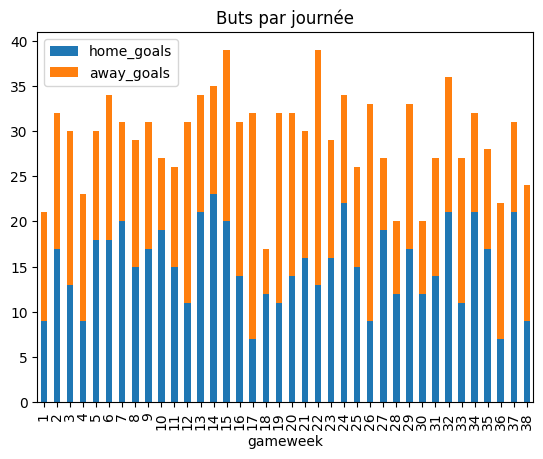

In [106]:
df_eda.groupby('gameweek')[['home_goals','away_goals']].sum().plot(kind='bar', stacked=True)
plt.title('Buts par journée')
plt.show()

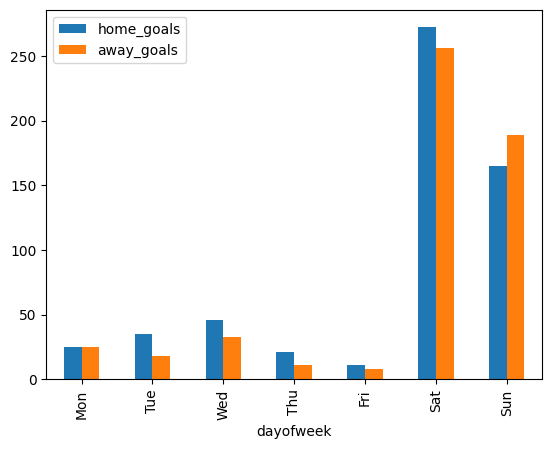

In [107]:
order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

df_eda['dayofweek'] = pd.Categorical(df_eda['dayofweek'], categories=order, ordered=True)

df_eda.groupby('dayofweek')[['home_goals','away_goals']].sum().plot(kind='bar')
plt.show()

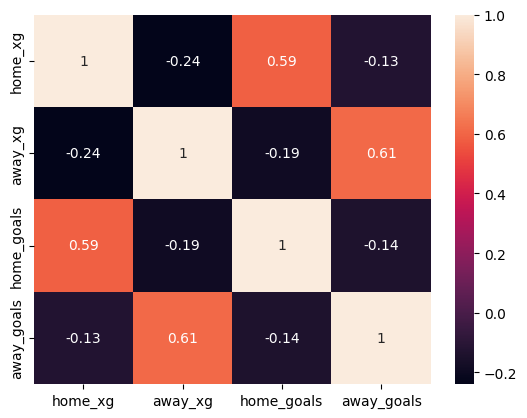

In [108]:
sns.heatmap(df_eda[['home_xg','away_xg','home_goals','away_goals']].corr(), annot=True)
plt.show()

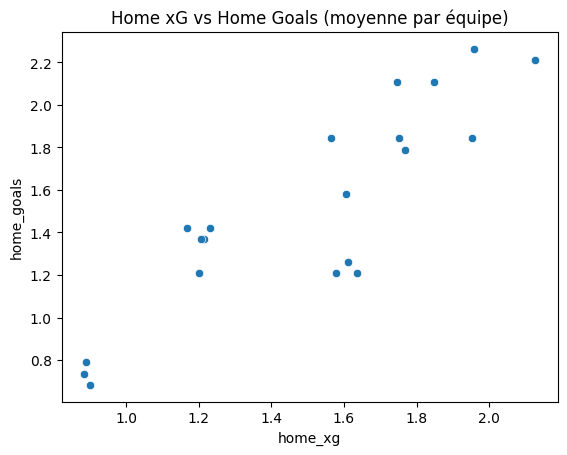

In [109]:
home_stats = df_eda.groupby('home_team')[['home_goals','home_xg']].mean()
sns.scatterplot(x='home_xg', y='home_goals', data=home_stats)
plt.title('Home xG vs Home Goals (moyenne par équipe)')
plt.show()

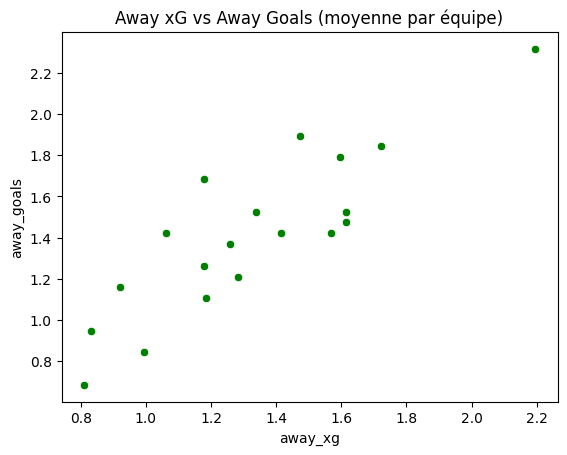

In [110]:
away_stats = df_eda.groupby('away_team')[['away_goals','away_xg']].mean()
sns.scatterplot(x='away_xg', y='away_goals', data=away_stats, color='green')
plt.title('Away xG vs Away Goals (moyenne par équipe)')
plt.show()

In [111]:
home_goals_by_team = df_eda.groupby('home_team')['home_goals'].sum()

top_home_scorer = home_goals_by_team.idxmax()
top_home_goals = home_goals_by_team.max()
print(f"Équipe qui a marqué le plus à domicile : {top_home_scorer} ({top_home_goals} buts)")

last_home_scorer = home_goals_by_team.idxmin()
last_home_goals = home_goals_by_team.min()
print(f"Équipe qui a marqué le moins à domicile : {last_home_scorer} ({last_home_goals} buts)")

Équipe qui a marqué le plus à domicile : Manchester City (43 buts)
Équipe qui a marqué le moins à domicile : Southampton (13 buts)


In [112]:
away_goals_by_team = df_eda.groupby('away_team')['away_goals'].sum()

top_away_scorer = away_goals_by_team.idxmax()
top_away_goals = away_goals_by_team.max()
print(f"Équipe qui a marqué le plus à l'extérieur : {top_away_scorer} ({top_away_goals} buts)")

last_away_scorer = away_goals_by_team.idxmin()
last_away_goals = away_goals_by_team.min()
print(f"Équipe qui a marqué le moins à l'extérieur : {last_away_scorer} ({last_away_goals} buts)")

Équipe qui a marqué le plus à l'extérieur : Liverpool (44 buts)
Équipe qui a marqué le moins à l'extérieur : Southampton (13 buts)


In [113]:
# Sup home
df_eda['home_outperform'] = df_eda['home_goals'] > df_eda['home_xg']
home_outperform_count = df_eda.groupby('home_team')['home_outperform'].sum()
top_home_outperformer = home_outperform_count.idxmax()
print(f"Équipe domicile qui a le plus souvent surpassé son xG : {top_home_outperformer} ({home_outperform_count.max()} fois)")


Équipe domicile qui a le plus souvent surpassé son xG : Newcastle Utd (15 fois)


In [114]:
# Sup away
df_eda['away_outperform'] = df_eda['away_goals'] > df_eda['away_xg']
away_outperform_count = df_eda.groupby('away_team')['away_outperform'].sum()
top_away_outperformer = away_outperform_count.idxmax()
print(f"Équipe extérieur qui a le plus souvent surpassé son xG : {top_away_outperformer} ({away_outperform_count.max()} fois)")

Équipe extérieur qui a le plus souvent surpassé son xG : Nott'ham Forest (14 fois)


In [115]:
# Sous-perf home
df_eda['home_underperform'] = df_eda['home_goals'] < df_eda['home_xg']
home_under_count = df_eda.groupby('home_team')['home_underperform'].sum()
top_home_under = home_under_count.idxmax()
print(f"Équipe domicile qui a le plus souvent sous-performé : {top_home_under} ({home_under_count.max()} fois)")

Équipe domicile qui a le plus souvent sous-performé : Crystal Palace (14 fois)


In [116]:
# Sous-perf away
df_eda['away_underperform'] = df_eda['away_goals'] < df_eda['away_xg']
away_under_count = df_eda.groupby('away_team')['away_underperform'].sum()
top_away_under = away_under_count.idxmax()
print(f"Équipe extérieur qui a le plus souvent sous-performé : {top_away_under} ({away_under_count.max()} fois)")

Équipe extérieur qui a le plus souvent sous-performé : Chelsea (13 fois)


In [117]:
df_eda['total_goals'] = df_eda['home_goals'] + df_eda['away_goals']
goals_by_team = df_eda.groupby('home_team')['home_goals'].sum() + df_eda.groupby('away_team')['away_goals'].sum()
top_total_goals = goals_by_team.idxmax()
print(f"Équipe avec le plus de buts : {top_total_goals} ({goals_by_team.max()} buts)")

Équipe avec le plus de buts : Liverpool (86 buts)


In [118]:
bottom_total_goals = goals_by_team.idxmin()
print(f"Équipe avec le moins de buts : {bottom_total_goals} ({goals_by_team.min()} buts)")

Équipe avec le moins de buts : Southampton (26 buts)


In [119]:
# Différence de buts à domicile : buts marqués à domicile - buts encaissés à domicile
home_goal_diff = df_eda.groupby('home_team').apply(
    lambda x: (x['home_goals'] - x['away_goals']).sum()
)

# Différence de buts à l’extérieur : buts marqués à l'extérieur - buts encaissés à l'extérieur
away_goal_diff = df_eda.groupby('away_team').apply(
    lambda x: (x['away_goals'] - x['home_goals']).sum()
)

In [120]:
total_goal_diff = home_goal_diff + away_goal_diff
best_diff_team = total_goal_diff.idxmax()
best_diff_value = total_goal_diff.max()
print(f"Équipe avec la plus grande différence de buts : {best_diff_team} ({best_diff_value})")

worst_diff_team = total_goal_diff.idxmin()
worst_diff_value = total_goal_diff.min()
print(f"Équipe avec la plus petite différence de buts : {worst_diff_team} ({worst_diff_value})")

Équipe avec la plus grande différence de buts : Liverpool (45)
Équipe avec la plus petite différence de buts : Southampton (-60)
